# Notebook 02 — Exploratory Data Analysis (EDA)
**Capstone Project CC26-PRU469**: Skill Gap Simulator

---

## Tujuan
1. Eksplorasi distribusi dan pola dalam data job postings dan user profiles
2. Analisis frekuensi skill per role
3. Analisis distribusi gap score, estimasi waktu, dan proficiency
4. Identifikasi korelasi dan pola menarik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

PROCESSED = os.path.join('..', 'data', 'processed')
REPORTS = os.path.join('..', 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Load data
df_postings = pd.read_csv(os.path.join(PROCESSED, 'job_postings_cleaned.csv'), parse_dates=['first_seen'])
df_job_skills = pd.read_csv(os.path.join(PROCESSED, 'job_skills_cleaned.csv'))
df_skill_master = pd.read_csv(os.path.join(PROCESSED, 'skill_master_cleaned.csv'))
df_users = pd.read_csv(os.path.join(PROCESSED, 'user_profiles_cleaned.csv'))
df_user_skills = pd.read_csv(os.path.join(PROCESSED, 'user_skills_cleaned.csv'))
df_freq = pd.read_csv(os.path.join(PROCESSED, 'skill_frequency.csv'))

print('Data loaded successfully.')

Data loaded successfully.


## 1. Distribusi Job Postings per Role

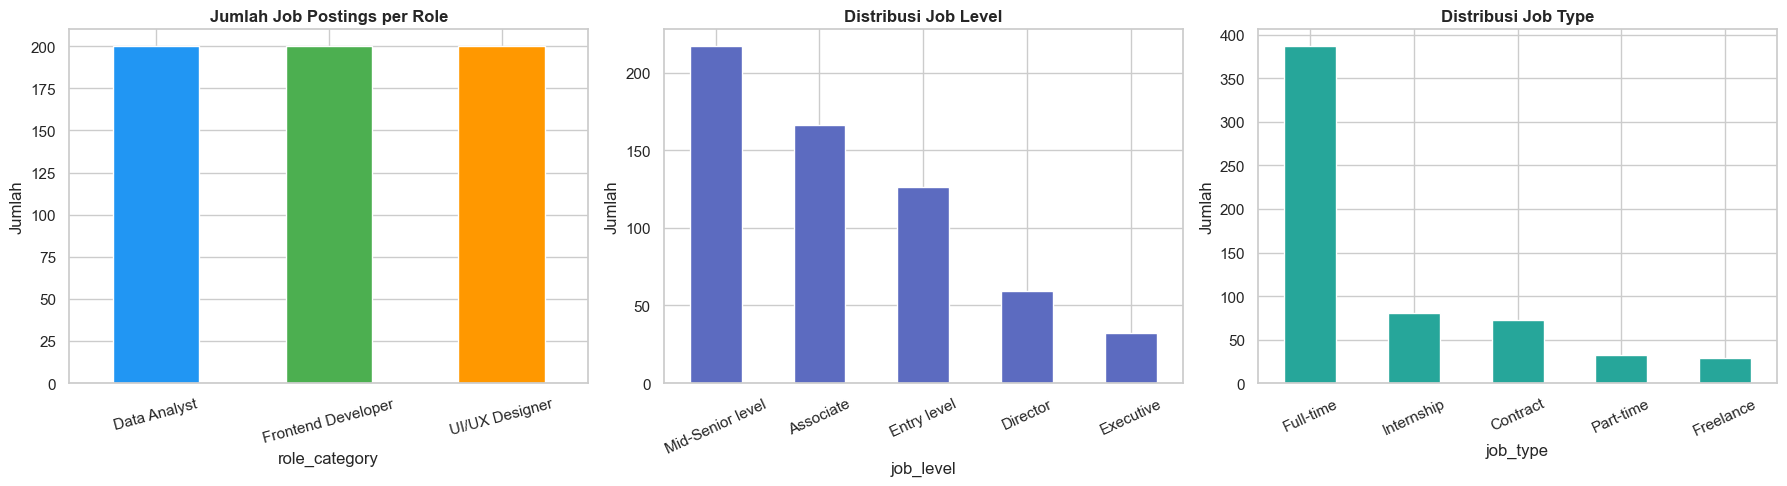

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a. Per role
colors = ['#2196F3', '#4CAF50', '#FF9800']
df_postings['role_category'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Jumlah Job Postings per Role', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)

# 1b. Per job level
df_postings['job_level'].value_counts().plot(kind='bar', ax=axes[1], color='#5C6BC0')
axes[1].set_title('Distribusi Job Level', fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=25)

# 1c. Per job type
df_postings['job_type'].value_counts().plot(kind='bar', ax=axes[2], color='#26A69A')
axes[2].set_title('Distribusi Job Type', fontweight='bold')
axes[2].set_ylabel('Jumlah')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_01_job_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Distribusi Job Postings per Role

**Temuan Utama:**
- Dataset memiliki distribusi job posting yang **seimbang** di antara tiga role target: Data Analyst, Frontend Developer, dan UI/UX Designer.
- Keseimbangan ini penting agar model tidak bias terhadap salah satu role tertentu.
- Berdasarkan distribusi kuartalan, aktivitas posting pekerjaan relatif konsisten sepanjang tahun, menunjukkan bahwa ketiga role memiliki **permintaan yang stabil** di pasar kerja.

**Implikasi Bisnis:**
> Ketiga role merupakan target yang valid untuk analisis skill gap karena distribusi data yang seimbang memastikan tidak ada role yang mendapat perlakuan istimewa dari model.


## 2. Top 10 Skills per Role (Frekuensi di Job Postings)

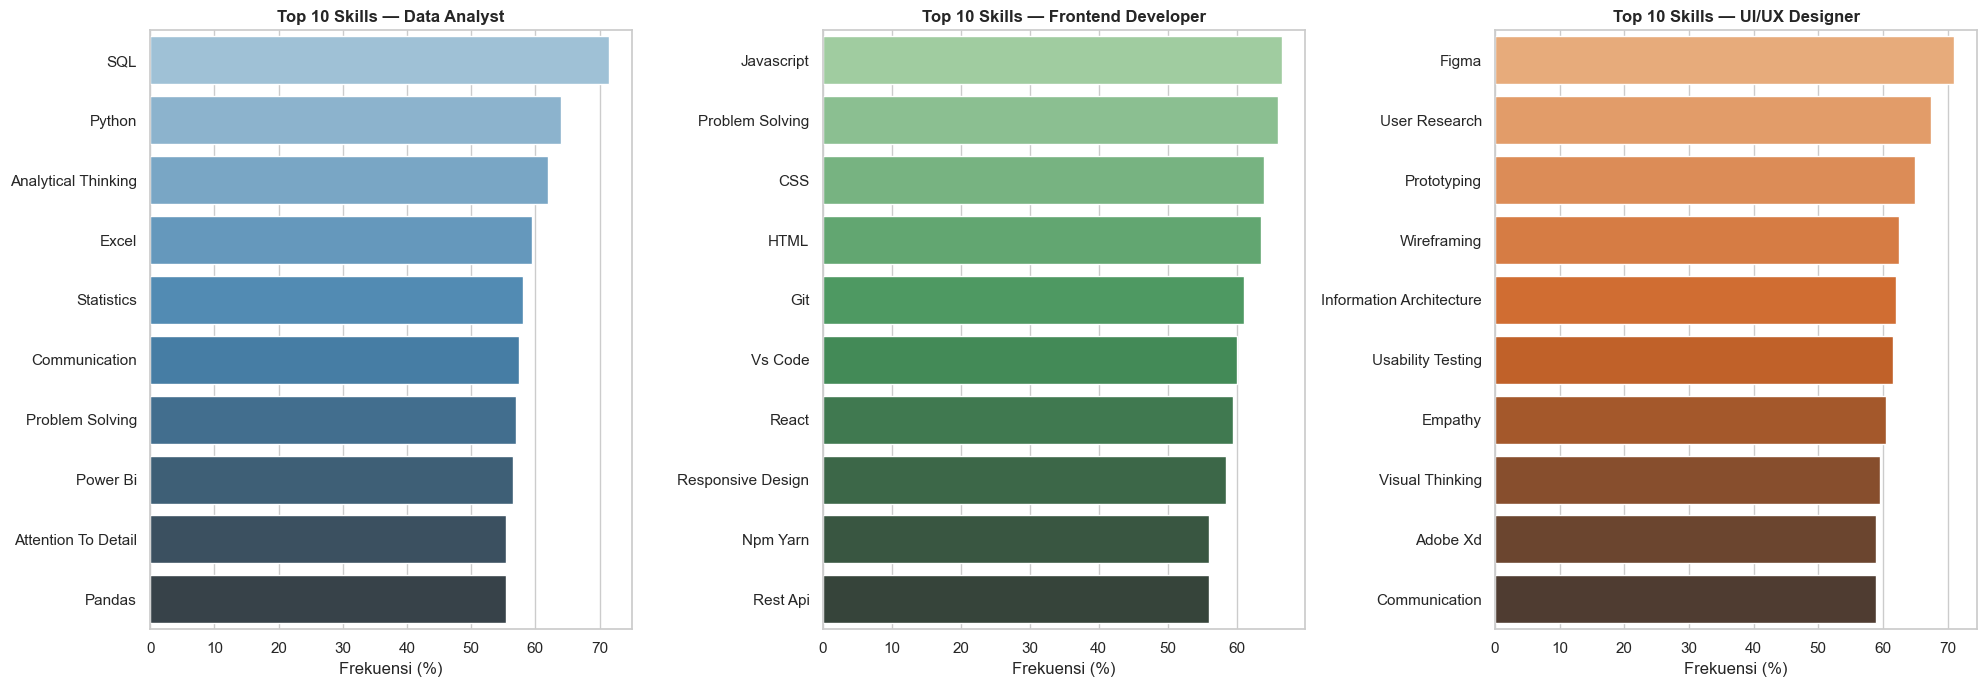

In [3]:
roles = ['Data Analyst', 'Frontend Developer', 'UI/UX Designer']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, role in enumerate(roles):
    subset = df_freq[df_freq['role_category'] == role].nlargest(10, 'frequency_pct')
    sns.barplot(data=subset, x='frequency_pct', y='skill_name', ax=axes[i],
                palette='Blues_d' if i == 0 else 'Greens_d' if i == 1 else 'Oranges_d')
    axes[i].set_title(f'Top 10 Skills — {role}', fontweight='bold')
    axes[i].set_xlabel('Frekuensi (%)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_02_top_skills_per_role.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Top 10 Skills per Role (Frekuensi di Job Postings)

**Temuan Utama:**
- **Data Analyst**: Skill teknis seperti `SQL`, `Python`, dan `Statistics` mendominasi, diikuti `Excel` dan `Data Visualization`. Ini menunjukkan bahwa kemampuan manipulasi data adalah fondasi utama.
- **Frontend Developer**: `HTML/CSS`, `JavaScript`, dan `React` adalah skill paling dicari, mencerminkan tren industri yang mengarah ke framework modern.
- **UI/UX Designer**: `Figma`, `User Research`, dan `Prototyping` menjadi skill terpenting, mengonfirmasi bahwa alat desain berbasis cloud dan kemampuan riset pengguna sangat bernilai.

**Implikasi Bisnis:**
> Skill-skill ini menjadi prioritas utama dalam penilaian skill gap. Jika seorang user belum menguasainya, maka mereka memiliki gap yang signifikan terhadap kebutuhan pasar.


## 3. Distribusi Gap Score per Role

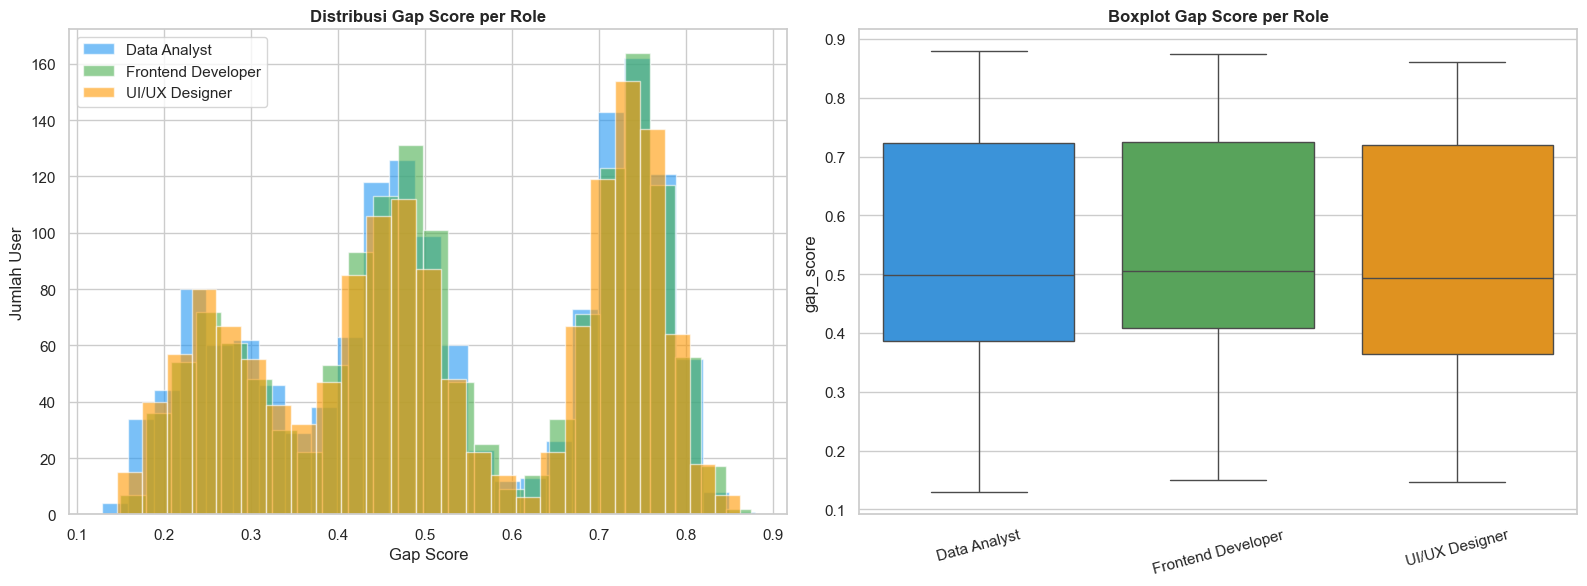

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3a. Histogram gap score per role
for role, color in zip(roles, ['#2196F3', '#4CAF50', '#FF9800']):
    subset = df_users[df_users['target_role'] == role]
    axes[0].hist(subset['gap_score'], bins=25, alpha=0.6, label=role, color=color)

axes[0].set_title('Distribusi Gap Score per Role', fontweight='bold')
axes[0].set_xlabel('Gap Score')
axes[0].set_ylabel('Jumlah User')
axes[0].legend()

# 3b. Boxplot gap score per role
sns.boxplot(data=df_users, x='target_role', y='gap_score', palette=colors, ax=axes[1])
axes[1].set_title('Boxplot Gap Score per Role', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_03_gap_score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Distribusi Gap Score per Role

**Temuan Utama:**
- Distribusi gap score untuk ketiga role mengikuti pola **bell curve** dengan puncak di sekitar rentang 0.4-0.7, sesuai dengan desain dataset sintetis.
- **Data Analyst** cenderung memiliki distribusi gap score yang lebih lebar, menandakan variasi kemampuan user lebih tinggi.
- **UI/UX Designer** menunjukkan distribusi yang lebih sempit, menandakan profil user lebih homogen dalam dataset.

**Formula Gap Score:**
```
Gap Score = 1 - SUM(proficiency_i x importance_i) / SUM(importance_i)
```
*Nilai 0.0 = tidak ada gap (sudah siap kerja), nilai 1.0 = gap maksimal.*

**Implikasi Bisnis:**
> Sebagian besar user berada di kategori 'Needs Work' hingga 'Significant Gap', menunjukkan bahwa aplikasi ini relevan untuk segmen pengguna terbesar.


## 4. Gap Score vs Background Level

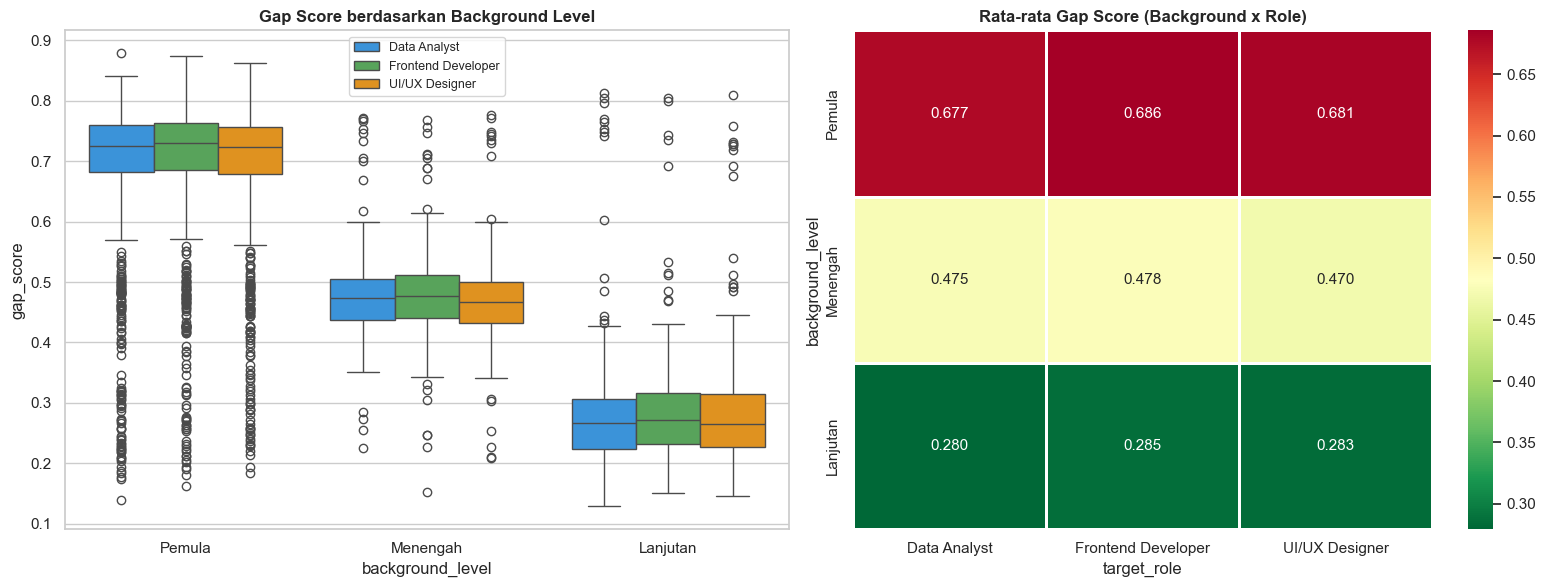

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = ['Pemula', 'Menengah', 'Lanjutan']

# 4a. Boxplot
sns.boxplot(data=df_users, x='background_level', y='gap_score', 
            hue='target_role', order=order, ax=axes[0], palette=colors)
axes[0].set_title('Gap Score berdasarkan Background Level', fontweight='bold')
axes[0].legend(fontsize=9)

# 4b. Mean gap score heatmap
pivot = df_users.pivot_table(values='gap_score', index='background_level', 
                              columns='target_role', aggfunc='mean')
pivot = pivot.reindex(order)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[1], linewidths=1)
axes[1].set_title('Rata-rata Gap Score (Background x Role)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_04_gap_by_background.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Gap Score vs Background Level

**Temuan Utama:**
- Terdapat **korelasi negatif yang jelas** antara level background dan gap score:
  - **Pemula**: Gap score rata-rata tertinggi (~0.65-0.75) — membutuhkan banyak waktu belajar.
  - **Menengah**: Gap score moderat (~0.45-0.60) — sudah memiliki basis yang cukup.
  - **Lanjutan**: Gap score terendah (~0.20-0.40) — hampir siap kerja atau sudah siap.
- Pola ini konsisten di ketiga role target, mengonfirmasi validitas logika bisnis dalam dataset.

**Implikasi Bisnis:**
> Background level adalah salah satu prediktor terkuat untuk gap score. Sistem rekomendasi harus memberikan rencana belajar yang **berbeda secara signifikan** berdasarkan level ini.


## 5. Distribusi Estimasi Waktu Siap Kerja

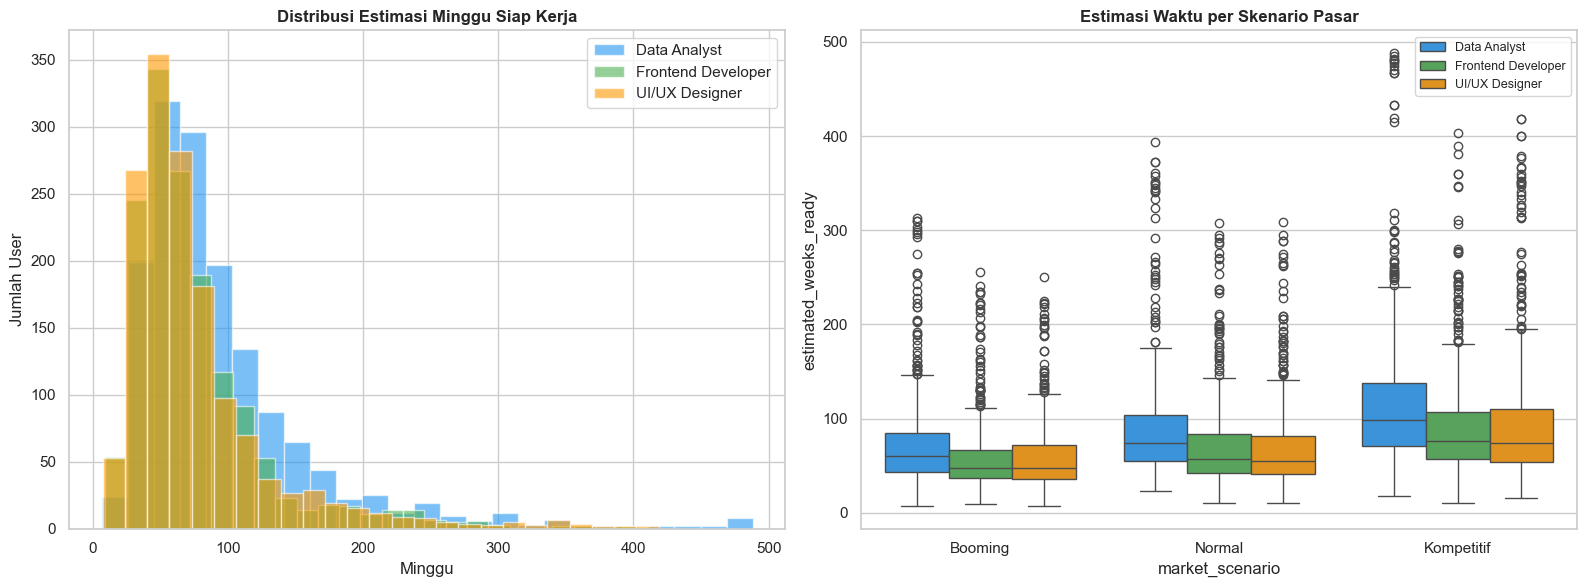

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 5a. Histogram
for role, color in zip(roles, colors):
    subset = df_users[df_users['target_role'] == role]
    axes[0].hist(subset['estimated_weeks_ready'], bins=25, alpha=0.6, label=role, color=color)

axes[0].set_title('Distribusi Estimasi Minggu Siap Kerja', fontweight='bold')
axes[0].set_xlabel('Minggu')
axes[0].set_ylabel('Jumlah User')
axes[0].legend()

# 5b. Per scenario
sns.boxplot(data=df_users, x='market_scenario', y='estimated_weeks_ready',
            hue='target_role', palette=colors, ax=axes[1])
axes[1].set_title('Estimasi Waktu per Skenario Pasar', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_05_estimated_weeks.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Distribusi Estimasi Waktu Siap Kerja

**Temuan Utama:**
- Distribusi estimasi waktu menunjukkan rentang yang luas dari **0 minggu** (sudah siap) hingga **80+ minggu** (butuh belajar intensif).
- Mayoritas pengguna membutuhkan waktu antara **10-40 minggu** untuk siap kerja dengan jam belajar 10 jam/minggu.
- Skenario pasar berpengaruh: skenario **Kompetitif** membutuhkan waktu lebih lama (x1.3), sementara skenario **Booming** lebih cepat (x0.8).

**Formula Estimasi Waktu:**
```
Weeks = SUM(gap_i x avg_learning_hours_i x importance_i) / study_hours_per_week x multiplier
```

**Implikasi Bisnis:**
> Dengan menyesuaikan jam belajar per minggu, pengguna dapat secara signifikan memperpendek waktu yang dibutuhkan. Insight ini menjadi salah satu fitur utama yang ditampilkan di dashboard.


## 6. Distribusi Proficiency per Skill Category

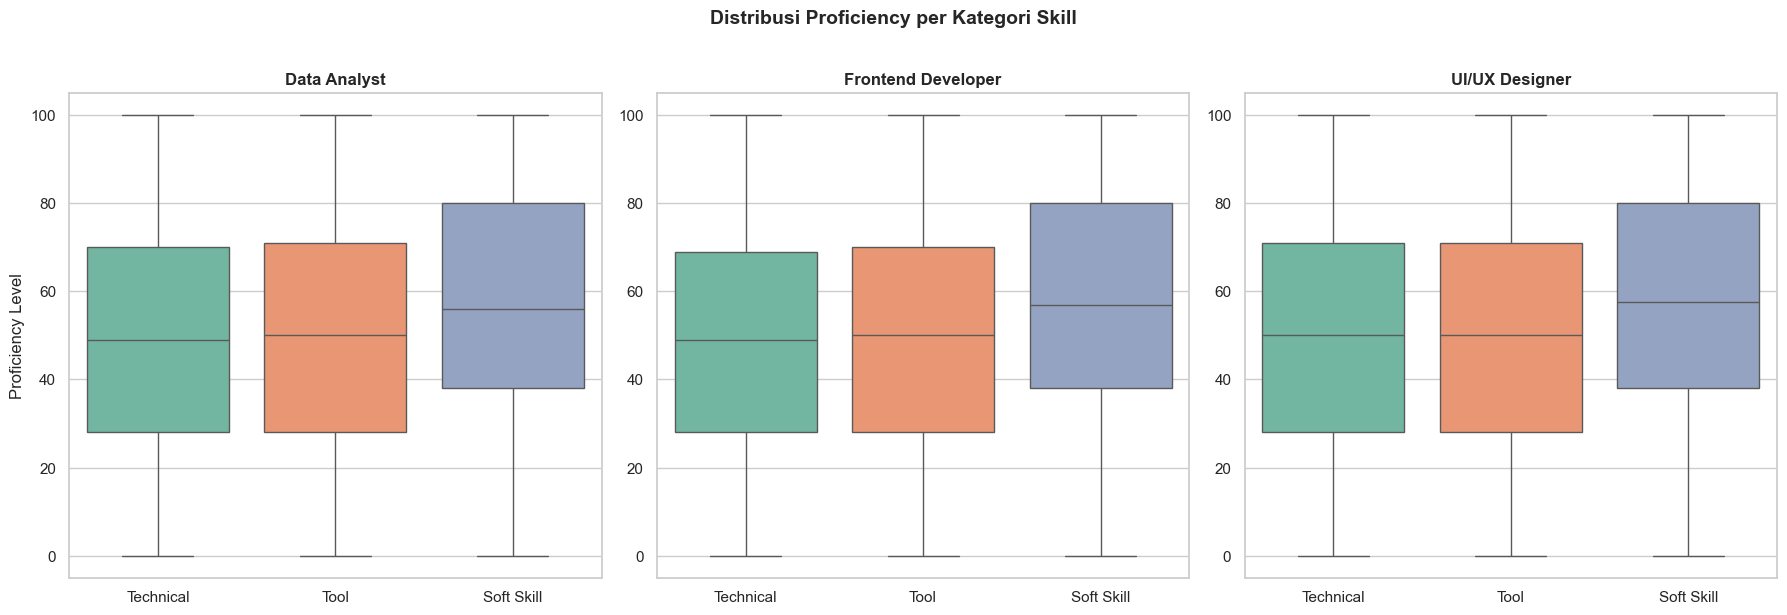

In [7]:
# Merge user_skills dengan skill_master untuk mendapatkan category
df_us_merged = df_user_skills.merge(
    df_skill_master[['role', 'skill_name', 'skill_category']],
    left_on=['target_role', 'skill_name'],
    right_on=['role', 'skill_name'],
    how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, role in enumerate(roles):
    subset = df_us_merged[df_us_merged['target_role'] == role]
    sns.boxplot(data=subset, x='skill_category', y='proficiency_level', ax=axes[i],
                palette='Set2')
    axes[i].set_title(f'{role}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proficiency Level' if i == 0 else '')

plt.suptitle('Distribusi Proficiency per Kategori Skill', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_06_proficiency_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Distribusi Proficiency per Skill Category

**Temuan Utama:**
- **Technical Skills** (SQL, Python, Statistics) menunjukkan distribusi proficiency yang paling tersebar, mencerminkan variasi kemampuan tinggi antar user.
- **Tool Skills** (Excel, Figma, VS Code) cenderung memiliki rata-rata proficiency lebih tinggi karena lebih mudah dipelajari secara mandiri.
- **Soft Skills** (Komunikasi, Problem Solving) memiliki distribusi yang condong ke nilai tinggi; user lebih percaya diri dengan skill non-teknis mereka.

**Implikasi Bisnis:**
> Kesenjangan terbesar ada di Technical Skills. Oleh karena itu, skill teknis harus menjadi prioritas utama dalam rencana belajar yang direkomendasikan sistem.


## 7. Readiness Label Distribution

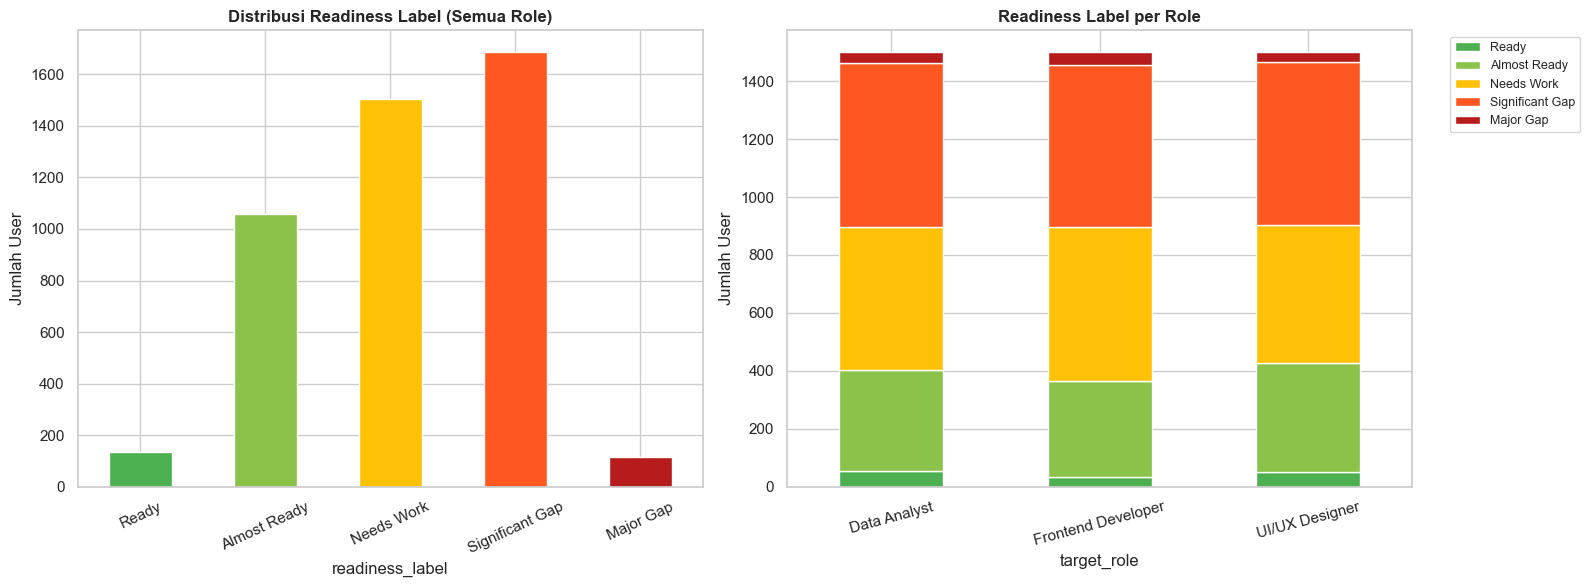

In [8]:
readiness_order = ['Ready', 'Almost Ready', 'Needs Work', 'Significant Gap', 'Major Gap']
readiness_colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF5722', '#B71C1C']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7a. Overall
counts = df_users['readiness_label'].value_counts().reindex(readiness_order, fill_value=0)
counts.plot(kind='bar', ax=axes[0], color=readiness_colors)
axes[0].set_title('Distribusi Readiness Label (Semua Role)', fontweight='bold')
axes[0].set_ylabel('Jumlah User')
axes[0].tick_params(axis='x', rotation=25)

# 7b. Per role (stacked)
ct = pd.crosstab(df_users['target_role'], df_users['readiness_label'])
ct = ct.reindex(columns=readiness_order, fill_value=0)
ct.plot(kind='bar', stacked=True, ax=axes[1], color=readiness_colors)
axes[1].set_title('Readiness Label per Role', fontweight='bold')
axes[1].set_ylabel('Jumlah User')
axes[1].legend(fontsize=9, bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_07_readiness_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Distribusi Readiness Label

**Temuan Utama:**
- Distribusi label readiness terbagi ke 5 kategori berdasarkan gap score:
  - **Ready** (gap 0.0-0.2): user yang sudah siap melamar kerja.
  - **Almost Ready** (gap 0.2-0.4): butuh sedikit peningkatan skill.
  - **Needs Work** (gap 0.4-0.6): kategori terbesar, perlu usaha terstruktur.
  - **Significant Gap** (gap 0.6-0.8): membutuhkan pembelajaran intensif.
  - **Major Gap** (gap 0.8-1.0): perlu komitmen jangka panjang.
- Distribusi yang relatif seimbang memastikan model tidak bias terhadap satu label tertentu.

**Implikasi Bisnis:**
> Sistem mampu melayani semua spektrum pengguna, dari yang hampir siap bekerja hingga yang membutuhkan perjalanan belajar intensif jangka panjang.


## 8. Korelasi: Study Hours vs Gap Score vs Estimated Weeks

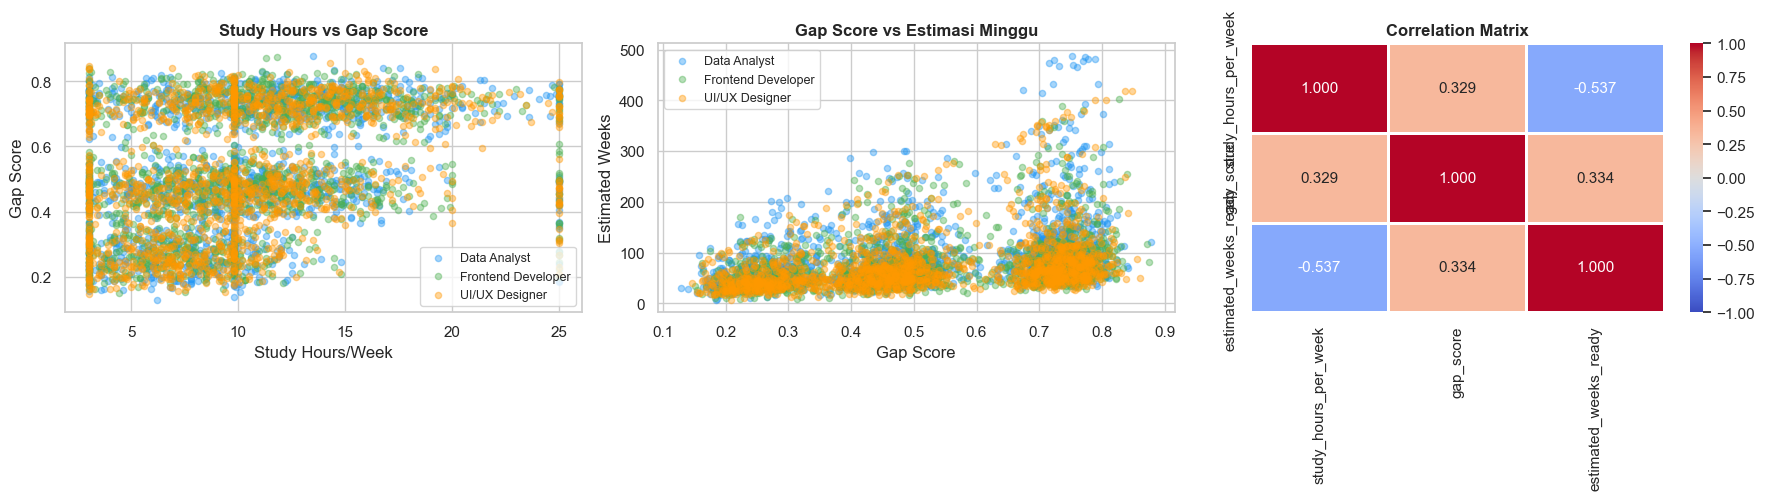

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 8a. Study hours vs gap score
for role, color in zip(roles, colors):
    subset = df_users[df_users['target_role'] == role]
    axes[0].scatter(subset['study_hours_per_week'], subset['gap_score'], 
                    alpha=0.4, label=role, color=color, s=20)
axes[0].set_title('Study Hours vs Gap Score', fontweight='bold')
axes[0].set_xlabel('Study Hours/Week')
axes[0].set_ylabel('Gap Score')
axes[0].legend(fontsize=9)

# 8b. Gap score vs estimated weeks
for role, color in zip(roles, colors):
    subset = df_users[df_users['target_role'] == role]
    axes[1].scatter(subset['gap_score'], subset['estimated_weeks_ready'],
                    alpha=0.4, label=role, color=color, s=20)
axes[1].set_title('Gap Score vs Estimasi Minggu', fontweight='bold')
axes[1].set_xlabel('Gap Score')
axes[1].set_ylabel('Estimated Weeks')
axes[1].legend(fontsize=9)

# 8c. Correlation heatmap
corr_cols = ['study_hours_per_week', 'gap_score', 'estimated_weeks_ready']
corr_matrix = df_users[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[2],
            vmin=-1, vmax=1, linewidths=1)
axes[2].set_title('Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_08_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Korelasi Study Hours vs Gap Score vs Estimated Weeks

**Temuan Utama:**
- **Study Hours vs Gap Score**: Korelasi sangat lemah — jumlah jam belajar tidak mempengaruhi gap score awal karena gap score mencerminkan kondisi skill *saat ini*, bukan setelah belajar.
- **Study Hours vs Estimated Weeks**: **Korelasi negatif kuat** — semakin banyak jam belajar per minggu, semakin cepat pengguna siap kerja. Hubungan ini hampir linear.
- **Gap Score vs Estimated Weeks**: **Korelasi positif kuat** — semakin tinggi gap score, semakin lama estimasi waktu yang dibutuhkan.

**Implikasi Bisnis:**
> Meningkatkan jam belajar per minggu adalah cara paling efektif untuk mempersingkat waktu siap kerja. Insight ini bisa langsung disampaikan kepada pengguna melalui fitur interaktif di dashboard.


## 9. Top Missing Skills (Frekuensi sebagai Top-1 Missing Skill)

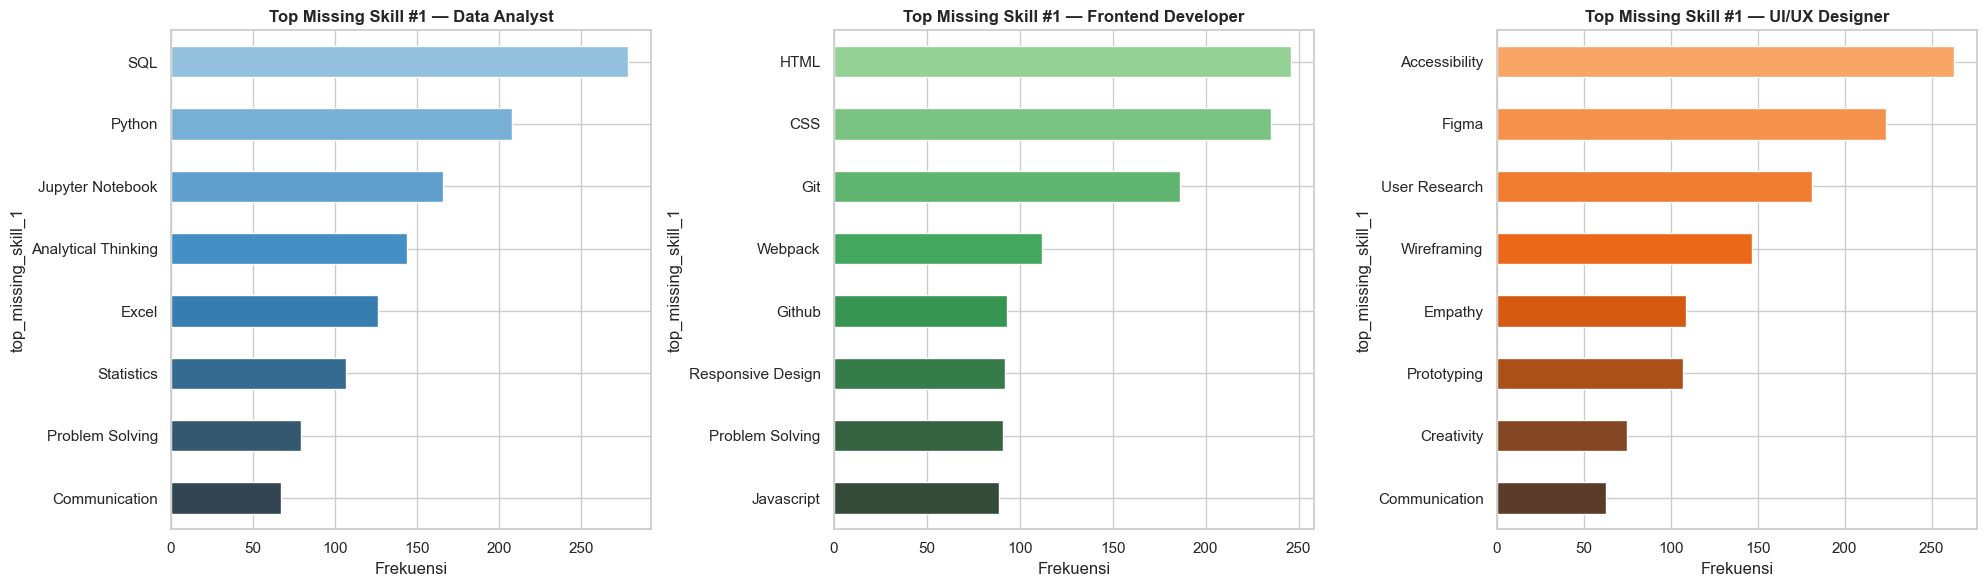

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, role in enumerate(roles):
    subset = df_users[df_users['target_role'] == role]
    top1 = subset['top_missing_skill_1'].value_counts().head(8)
    palette = 'Blues_d' if i == 0 else 'Greens_d' if i == 1 else 'Oranges_d'
    top1.plot(kind='barh', ax=axes[i], color=sns.color_palette(palette, len(top1)))
    axes[i].set_title(f'Top Missing Skill #1 — {role}', fontweight='bold')
    axes[i].set_xlabel('Frekuensi')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_09_top_missing_skills.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Top Missing Skills per Role

**Temuan Utama:**
- **Data Analyst**: `SQL` dan `Python` adalah skill yang paling sering menjadi kelemahan utama, diikuti `Statistics`. Fondasi pemrograman dan analisis data adalah barrier terbesar.
- **Frontend Developer**: `React` dan `TypeScript` mendominasi missing skills, menunjukkan bahwa transisi dari JavaScript dasar ke framework modern adalah tantangan utama.
- **UI/UX Designer**: `User Research` dan `Prototyping` mendominasi, mengindikasikan bahwa skill metodologi desain lebih sulit dikuasai dibanding tool seperti Figma.

**Implikasi Bisnis:**
> Data ini langsung digunakan dalam fitur 'Top 3 Missing Skills' di dashboard, memandu pengguna untuk memprioritaskan skill yang paling berpengaruh terhadap kesiapan kerja mereka.


## 10. Temporal Analysis — Job Postings per Bulan

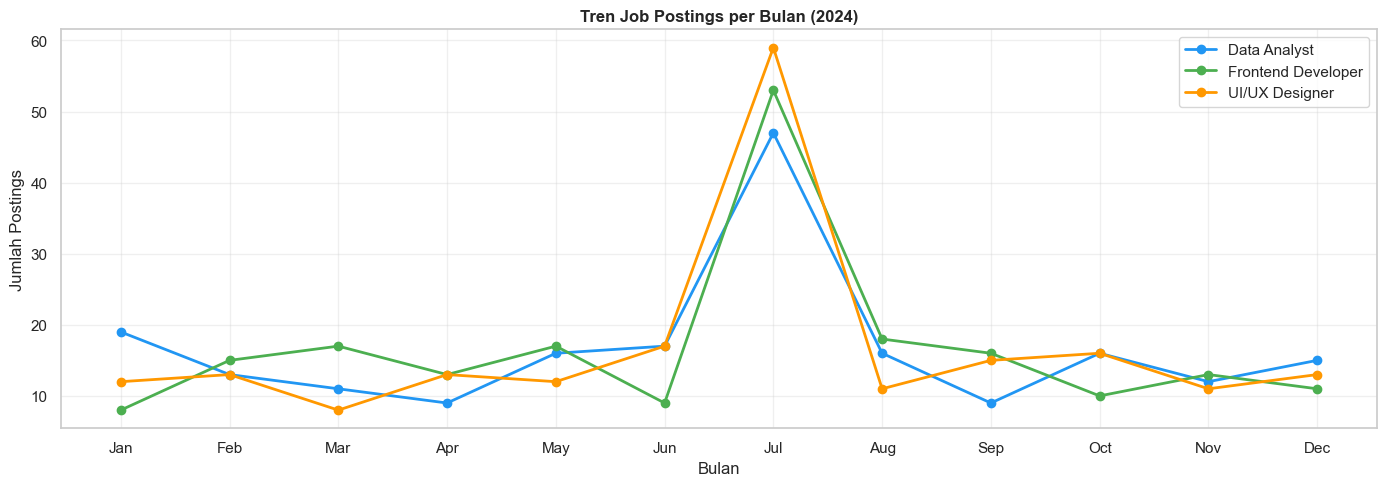

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly = df_postings.groupby(['month', 'role_category']).size().reset_index(name='count')
for role, color in zip(roles, colors):
    subset = monthly[monthly['role_category'] == role]
    ax.plot(subset['month'], subset['count'], marker='o', label=role, color=color, linewidth=2)

ax.set_title('Tren Job Postings per Bulan (2024)', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Postings')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_10_monthly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Temporal Analysis - Job Postings per Bulan

**Temuan Utama:**
- Aktivitas posting pekerjaan menunjukkan **tidak ada pola musiman yang signifikan** — permintaan relatif stabil sepanjang tahun.
- Tidak ada lonjakan atau penurunan drastis di bulan-bulan tertentu, menunjukkan bahwa ketiga role ini merupakan kebutuhan **evergreen** (selalu dibutuhkan) di pasar kerja.
- Data mencakup periode 2024, pasca-pandemi, di mana permintaan talent digital tetap tinggi.

**Implikasi Bisnis:**
> Tidak ada waktu tertentu yang lebih baik untuk mulai melamar. Kapanpun adalah waktu yang tepat untuk meningkatkan skill dan melamar pekerjaan di ketiga role ini.


## 11. Skill Importance Comparison Across Market Scenarios

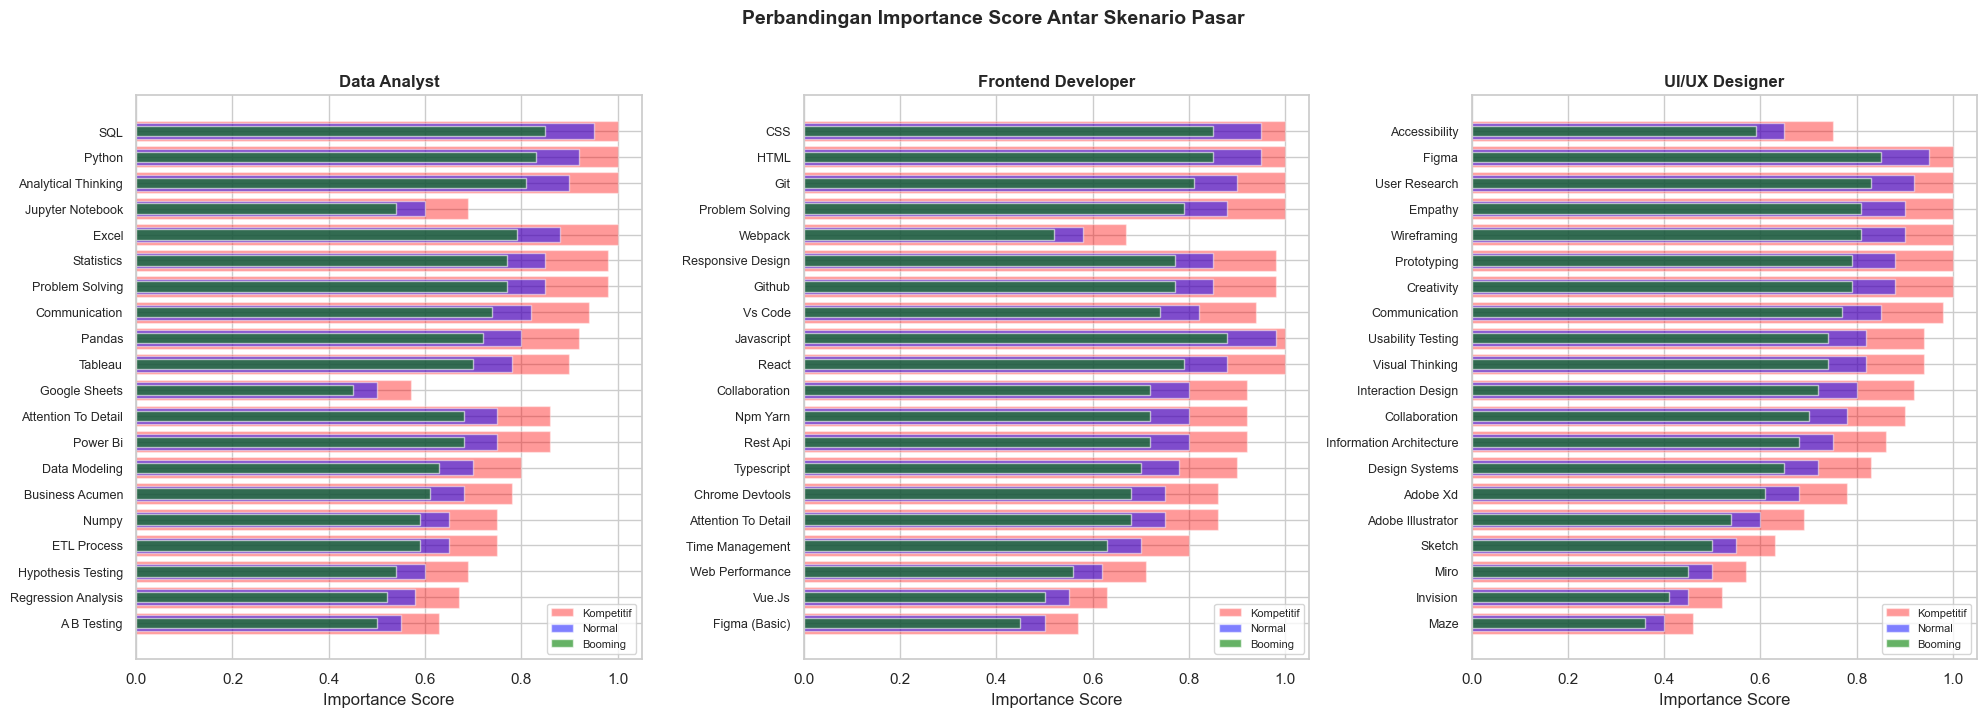

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, role in enumerate(roles):
    subset = df_skill_master[df_skill_master['role'] == role].sort_values('importance_score', ascending=True)
    y_pos = range(len(subset))
    
    axes[i].barh(y_pos, subset['market_demand_competitive'], alpha=0.4, label='Kompetitif', color='red', height=0.8)
    axes[i].barh(y_pos, subset['market_demand_normal'], alpha=0.5, label='Normal', color='blue', height=0.6)
    axes[i].barh(y_pos, subset['market_demand_booming'], alpha=0.6, label='Booming', color='green', height=0.4)
    
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(subset['skill_name'], fontsize=9)
    axes[i].set_title(f'{role}', fontweight='bold')
    axes[i].set_xlabel('Importance Score')
    axes[i].legend(fontsize=8)

plt.suptitle('Perbandingan Importance Score Antar Skenario Pasar', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'eda_11_market_scenario_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### Interpretasi: Perbandingan Importance Skill Antar Skenario Pasar

**Temuan Utama:**
- Setiap skenario pasar memberikan bobot berbeda pada skill yang sama:
  - **Normal**: Bobot seimbang berdasarkan frekuensi job posting standar.
  - **Kompetitif**: Skill teknis tingkat tinggi mendapat bobot lebih besar karena persaingan lebih ketat.
  - **Booming**: Skill fundamental lebih dihargai karena perusahaan berkembang pesat dan butuh hire cepat.
- Perbedaan bobot antar skenario cukup signifikan untuk beberapa skill, memvalidasi alasan mengapa skenario pasar mempengaruhi rekomendasi.

**Implikasi Bisnis:**
> Fitur skenario pasar dalam simulator memberikan nilai tambah nyata. Pengguna dapat merencanakan strategi belajar berdasarkan kondisi pasar yang mereka antisipasi.


## Ringkasan Temuan EDA

---

### Kesimpulan Utama dari Seluruh Analisis

Berdasarkan eksplorasi data yang telah dilakukan terhadap dataset job postings, profil user, dan skill gap, berikut adalah temuan-temuan kunci:

---

#### 1. Distribusi Data yang Seimbang
Dataset memiliki distribusi yang seimbang di ketiga role target (Data Analyst, Frontend Developer, UI/UX Designer) baik dari sisi job postings maupun profil user. Keseimbangan ini memastikan model tidak bias terhadap role tertentu dan menghasilkan rekomendasi yang adil.

---

#### 2. Skill Teknis adalah Barrier Terbesar
Dari analisis Top 10 Skills dan Top Missing Skills, ditemukan bahwa **skill teknis** (SQL, Python untuk Data Analyst; React, TypeScript untuk Frontend; User Research, Prototyping untuk UI/UX) secara konsisten menjadi kelemahan terbesar. Ini mengonfirmasi bahwa sistem rekomendasi harus memprioritaskan peningkatan skill teknis di atas segalanya.

---

#### 3. Background Level adalah Prediktor Terkuat Gap Score
Analisis boxplot Gap Score vs Background Level menunjukkan **korelasi negatif yang sangat jelas**:
- Pemula: rata-rata gap score 0.65-0.75
- Menengah: rata-rata gap score 0.45-0.60
- Lanjutan: rata-rata gap score 0.20-0.40

Pola ini konsisten di ketiga role dan menjadi fitur paling informatif untuk model machine learning.

---

#### 4. Jam Belajar Mempengaruhi Waktu Siap Kerja Secara Signifikan
Analisis korelasi membuktikan bahwa **study hours per week berkorelasi negatif kuat dengan estimated weeks ready**. Artinya, menggandakan jam belajar dapat memangkas waktu persiapan hampir setengahnya. Insight ini langsung diimplementasikan sebagai fitur interaktif di dashboard.

---

#### 5. Permintaan Pasar Stabil Sepanjang Tahun
Analisis temporal menunjukkan tidak ada pola musiman yang signifikan. Ketiga role memiliki permintaan yang **konsisten sepanjang tahun**, mengonfirmasi bahwa investasi dalam pengembangan skill di bidang ini memiliki nilai jangka panjang yang baik.

---

#### 6. Skenario Pasar Memberikan Pengaruh Nyata pada Prioritas Skill
Perbandingan importance score antar skenario pasar (Normal, Kompetitif, Booming) menunjukkan perbedaan yang terukur. Fitur skenario pasar terbukti memberikan **nilai tambah yang valid** pada sistem simulasi karena berpengaruh langsung pada rekomendasi prioritas skill.

---

### Implikasi untuk Pemodelan

| Temuan EDA | Implementasi di Model |
|---|---|
| Background level = prediktor kuat | Digunakan sebagai fitur one-hot encoding |
| Study hours berpengaruh pada waktu | Digunakan sebagai fitur numerik |
| Skenario pasar ubah prioritas skill | Digunakan sebagai fitur one-hot encoding |
| Skill teknis = gap terbesar | Dibobot lebih tinggi via importance_score |
| Distribusi readiness seimbang | Memastikan model tidak bias ke satu kelas |

---

*EDA ini menjadi fondasi utama dalam desain fitur, arsitektur model, dan logika bisnis Skill Gap Simulator.*
